<CENTER><img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/images/ATLASOD.gif?raw=1" style="width:50%"></CENTER>

# Missing Transverse Energy



In High Energy Physics, the concept of missing energy is a double edged sword. When something doesn't interact very much with other particles, such as neutrinos, or possibly, dark matter, missing energy could be the best way we have to find them. However, weakly interacting particles aren't the only reasons energy can go missing. Aging or innacurate detector components, bugs in our complex simulations and reconstructions, particles sneaking by or interacting with the detector, and even simple run-to-run variance (see [Good Runs List](https://opendata.atlas.cern/docs/documentation/data_collection/GRL_definition)) can generate all sorts of noise and errors which cause missing energy to crop up. So how do we prevent missing energy from running amok in an analysis?

To start, we have to identify it! And our first step begins in using some tricks with the [Conservation of Momentum](https://cds.cern.ch/record/2759491/files/Conservation%20Laws%20-%20ATLAS%20Physics%20Cheat%20Sheet.pdf). By reading the measurable particles produced in a collision and counting up the imbalance in mass from their parent particles, we can approximate the momentum carried away by errors and runaway particles. This inferred imbalance is called **missing transverse momentum**, commonly referred to as **missing transverse energy**, or MET.

In this notebook, we will use [Monte Carlo](https://cds.cern.ch/record/2922919/files/Monte%20Carlo%20Simulation.pdf) simulated data to investigate:

1. How does missing transverse energy appear in a sample?
2. How accurately are these energies reconstructed?
3. How do hadronic jets make our neutrino detecting more difficult?
4. How can we identify neutrinos in an analysis?

To do this, we'll look at how much energy we're actually missing, calculate , analyze how much of the true energy the detector is actually reconstructing, identify some neutrinos, and look at any extra powerful events that might influence our data. We'll stick to Monte Carlo simulated data in this demonstration, so we can use the inital simulation conditions, known as the "truth record" as a cheat sheet to compare with our reconstructed information. If we were to use detector data, we wouldn't have the parent particles to compare things to, and we'd have to work backwards completely!

## Why transverse?

We can set this up by thinking about the $xyz$ plane. If you imagine a line along $z$-axis, running towards you/away from you, you may notice that the traditional $x$ and $y$ axes will intersect with this line at 90 degrees (such that they are all perpendicular). The $xy$ plane, in this situation, would be trans- (to pass through) -verse (to turn around) to the $z$ axis. Replace the $z$-axis with with a 13.6 TeV (tera-electron-volt) proton beam and toss in the ATLAS detector, and you've got a good idea of how we construct coordinates in the LHC!

A particle's transverse momentum is defined as the vector created by the composition of coordinates in the $x$ and $y$ direction,

$$
p_T=\sqrt{p_x^2+p_y^2}.
$$

Although the momenta of the protons in the beam are known, the quarks and gluons taking part in each event carry different, unknown fractions of their parent protons' momenta. We therefore cannot definitively know the initial momentum of every hard collision event by event.

To simplify our analysis, the events we will be looking at will have a net momentum of zero. Why is this? Protons in the beam generally only travel in the Z direction, with near-zero movement in the transverse plane. However, when a collision occurs in the LHC, the newly produced particles from the scattering fly off along the transverse plane. Via the conservation of momentum, the transverse momentum of these new particles must therefore sum to zero to match the transverse momentum of their parent particle. This gives use a useful equivalence which we can manipulate:

$$
\sum_{\mathrm{visible}}\vec p_T
+
\sum_{\mathrm{invisible}}\vec p_T
\approx 0.
$$

If this is true, then the missing momentum will be the momentum required to cancel out the remaining transverse momentum from the measured particles or:

$$
\vec p_T^{\,\mathrm{miss}}
=
-\sum_{\mathrm{visible}}\vec p_T.
$$

Suppose a $Z$ boson produces two visible muons whose combined transverse momentum is $(100,0)$ GeV. Other visible particles must provide approximately $(-100,0)$ GeV of recoil if nothing invisible is produced. If we reconstruct that recoil as only $(-80,0)$ GeV, the visible sum becomes $(20,0)$ GeV. We infer a missing vector of $(-20,0)$ GeV even though the example contains no invisible particle. However, if our sample did contain neutrinos, an invisible particle, we could instead infer that it is the neutrino that carried away that energy instead. Therefore, we can never be entirely sure where MET comes from based on this sort of calculation alone. 

### Notation

To simplify things: instead of saying "MET" but showing momentum, we'll use $E^{\mathrm{miss}}$ notation throughout the plots, where:

$$
E_x^{\mathrm{miss}}=p_x^{\mathrm{miss}},
\qquad
E_y^{\mathrm{miss}}=p_y^{\mathrm{miss}},
$$

$$
E_T^{\mathrm{miss}}
=
\sqrt{
(E_x^{\mathrm{miss}})^2+
(E_y^{\mathrm{miss}})^2
}.
$$

Thus, $E_x^{\mathrm{miss}}$ and $E_y^{\mathrm{miss}}$ are momentum components despite the use of the letter $E$. The magnitude $E_T^{\mathrm{miss}}$ is non-negative. We use natural units, with $c=1$, so momenta are expressed in GeV (giga-electron-volts).

### Running a Jupyter Notebook

To run the whole Jupyter notebook, in the top menu click Cell $\rightarrow$ Run All.

To propagate a change you've made to a piece of code, click Cell $\rightarrow$ Run All Below.

You can also run a single code cell, by using the keyboard shortcut Shift+Enter.

### First time setup on your computer (Skip on MyBinder)
This first cell only needs to be run the first time you open this notebook on your computer.

If you close Jupyter and re-open it on the same computer, you won't need to run this first cell again.

If you open the notebook on mybinder, you don't need to run this cell.

In [ ]:
#install required packages  
%pip install atlasopenmagic
from atlasopenmagic import install_from_environment
install_from_environment()

### To setup everytime
We're going to be using a number of tools to help us:
* pandas: lets us store data as dataframes, a format widely used in Python
* uproot: lets us read .root files typically used in particle physics into data formats used in Python
* numpy: provides numerical calculations such as histogramming
* matplotlib: common tool for making plots, figures, images, visualisations
* awkward: a python package for dealing conveniently with lists that are different lengths
* vector: a python package for making and manipulating vectors

In case you see an error when importing one of these packages, try restarting the kernel (the "session" in Colab) to make sure the packages that were installed in the last cell have been properly loaded.

In [2]:
import pandas as pd # to store data as dataframes
import numpy as np # for numerical calculations such as histogramming
import uproot # to read .root files as dataframes
import matplotlib.pyplot as plt # for plotting
from matplotlib.ticker import AutoMinorLocator # for minor ticks
import awkward as ak # for handling complex and nested data structures efficiently
import vector # For convenient 4-vector manipulation
import atlasopenmagic as atom # for ATLAS-specific plotting and analysis tools
vector.register_awkward()

## Our Analysis

<div style="display: flex; justify-content: center; align-items: center; gap: 20px;"><img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/13-TeV-examples/uproot_python/images/WZimages/Zll_decay.png?raw=true" style="width: 40%;"><img src="https://github.com/atlas-outreach-data-tools/notebooks-collection-opendata/blob/master/13-TeV-examples/uproot_python/images/WZimages/Wlv_decay.png?raw=true" style="width: 40%;">
</div>

For this analysis, we'll use a variety of samples, focusing on the $Z \to\mu\mu$ and $W \to\ell\nu$ decay channels. These decays are represented above using [Feynman Diagrams](https://cds.cern.ch/record/2759490/files/Feynman%20Diagrams%20-%20ATLAS%20Cheat%20Sheet.pdf). From this, we can infer that our W decay sample should contain intrinsic missing energy from its neutrino, while the Z decay sample should not, as both decays are muons, which interact with the detector. This allows us to analyze the behavior of MET in samples which should contain them, and compare this to samples which should not. We'll use Monte Carlo data to simplify this work, giving us our initial masses at the onset, as $W$ and $Z$ bosons have observed [invariant mass](https://cds.cern.ch/record/2919871/files/4-vectors%20and%20invariant%20mass%20cheat%20sheet.pdf) values.

We'll pull two samples: a sample including both W and Z decays, giving us a prompt source of MET via neutrinos, and a sample including only the Z decay, with no intended source of MET. Our first sample, the $Z \to\mu\mu$ sample, is represented with the physics short `Sh_2211_Zmumu_maxHTpTV2_CVetoBVeto`. This exposes a few things to us: we're using the Sherpa event generator version 2.2.11, our prompt event is $Z \to\mu\mu$, our data is categorized by the maximum between $H_T$ and $p_T^{{V}}$ values, and all b and b hadronic jets are removed from the reconstruction (vetoed). We can synthesize similar info from the $WZ \to\ell\ell\ell\nu$ sample short as well, which is `Sh_2212_lllv`. If you want to dig deeper into what these datasets contain, try using the `print_metadata()` function on ATLASOpenMagic!

In [ ]:
# This will set our release to the updated 13 TeV release to pull the latest MC data.
atom.set_release("2025e-13tev-beta")

# We'll use this to retrieve the data files from ATLAS Open Data. This creates a list of files that we can use to build a tree for analysis.
# We'll use the root (xrootd) protocol to access the files directly from the ATLAS Open Data server. If this does not work for you, change "root" to "https"
zmumu_urls = atom.get_urls("Sh_2211_Zmumu_maxHTpTV2_CVetoBVeto", skim="2muons", protocol="root", cache=False)
wz_urls = atom.get_urls( "Sh_2212_lllv", skim="noskim", protocol="root", cache=False)

# Here we'll build a two separate trees using the files we just pulled, using uproot to view the root files.
zmumu_tree = uproot.open(zmumu_urls[0])["analysis"]
wz_tree = uproot.open(wz_urls[0])["analysis"]

# And we'll print the amount of events available to choose from
print(f"Events available: {zmumu_tree.num_entries:,}")
print(f"Events available: {wz_tree.num_entries:,}")

### What does MET look like? 

We'll start by pulling all of the $E_T^{\mathrm{miss}}$ values for the events in the $WZ$ and $Z\to\mu\mu$ samples. We're only going to pull the first ~500,000 events from each set, as that should be more than enough to see waht we want to see. In our $WZ$ sample, we are guaranteed neutrinos, which are direct sources of MET, so we'll most definitely see a good amount of MET in this sample. What we're going to investigate is how, in our $Z$ sample, though we only generate and reconstruct muons, there's a good chance we'll see a similar amount of MET. The code cell below will frontload all of the data we'll need in this analysis, and will allow us to use this data first in comparison.

In [ ]:
max_events = 500_000
batch_size = 100_000

# Z→mumu: load the quantities needed for the MET spectrum, residuals, resolution, and high-MET plots.
zmumu_scalar_branches = [
    "met", 
    "met_mpx", 
    "met_mpy", 
    "truth_met", 
    "truth_met_phi"
]

# We'll also load the jet pt and eta for the HT calculation, which is used in the residuals and resolution plots.
zmumu_branches = zmumu_scalar_branches + ["jet_pt", "jet_eta"]
zmumu_parts = {name: [] for name in zmumu_scalar_branches + ["ht"]}

# We'll iterate through the Zmumu tree in batches, loading the specified branches and calculating HT for each event.
for batch in zmumu_tree.iterate(
    expressions=zmumu_branches,
    entry_stop=max_events,
    step_size=batch_size,
    library="ak",
):
    for name in zmumu_scalar_branches:
        zmumu_parts[name].append(
            np.asarray(ak.to_numpy(batch[name]), dtype=np.float64)
        )

    # We'll calculate HT for each event by summing the pt of all jets that pass the selection criteria (pt > 20 GeV and |eta| < 2.5).
    selected_jets = (
        (batch["jet_pt"] > 20)
        & (np.abs(batch["jet_eta"]) < 2.5)
    )
    batch_ht = np.asarray(
        ak.to_numpy(ak.sum(batch["jet_pt"][selected_jets], axis=1)),
        dtype=np.float64,
    )

    # We'll filter out events with invalid jet pt or eta values, setting HT to NaN for those events.
    valid_jets = np.asarray(
        ak.to_numpy(
            ak.all(
                np.isfinite(batch["jet_pt"])
                & np.isfinite(batch["jet_eta"]),
                axis=1,
            )
        ),
        dtype=bool,
    )
    batch_ht[~valid_jets] = np.nan
    zmumu_parts["ht"].append(batch_ht)

if not zmumu_parts["met"]:
    raise ValueError("No Z→μμ events were loaded.")

# Combine the parts into a single array for each branch and filter out invalid events
zmumu = {
    name: np.concatenate(parts)
    for name, parts in zmumu_parts.items()
}
zmumu_valid = np.logical_and.reduce([
    np.isfinite(values) for values in zmumu.values()
])
zmumu = {
    name: values[zmumu_valid] for name, values in zmumu.items()
}

# WZ: load once for the second MET panel and the scale graph.
wz_branches = ["met", "truth_met"]
wz_parts = {name: [] for name in wz_branches}

# We'll iterate through the WZ tree in batches, loading the specified branches.
for batch in wz_tree.iterate(
    expressions=wz_branches,
    entry_stop=max_events,
    step_size=batch_size,
    library="np",
):
    for name in wz_branches:
        wz_parts[name].append(
            np.asarray(batch[name], dtype=np.float64)
        )

if not wz_parts["met"]:
    raise ValueError("No WZ events were loaded.")

# Combine the parts into a single array for each branch and filter out invalid events
wz = {
    name: np.concatenate(parts)
    for name, parts in wz_parts.items()
}

# We'll filter out events with invalid MET or truth MET values, keeping only those events where both are finite.
wz_valid = np.isfinite(wz["met"]) & np.isfinite(wz["truth_met"])
wz = {name: values[wz_valid] for name, values in wz.items()}

# Print the number of events retained after filtering for valid data
print(f"Z→μμ events retained: {len(zmumu['met']):,}")
print(f"WZ events retained: {len(wz['met']):,}")

Great! Now we can set up a plot to visualize the MET in each sample. We'll plot the amount of MET as a function multiplicity. That is to say, we'll have MET "bins" on the x-axis, and counts for events on the y-axis, showing us how many events are missing each amount of energy. These "bins" will be set up such that each vertical bar accounts for a 20 GeV interval, and every event with a MET value in that 20 GeV interval will be represented by that bar.

Before running it, stop to think:

- Should $Z\to\mu\mu$ appear only at exactly zero MET?
- Which sample should have more MET on average?
- If you find one $Z\to\mu\mu$ event at very high reconstructed MET, can we infer anything about its source from this graph?


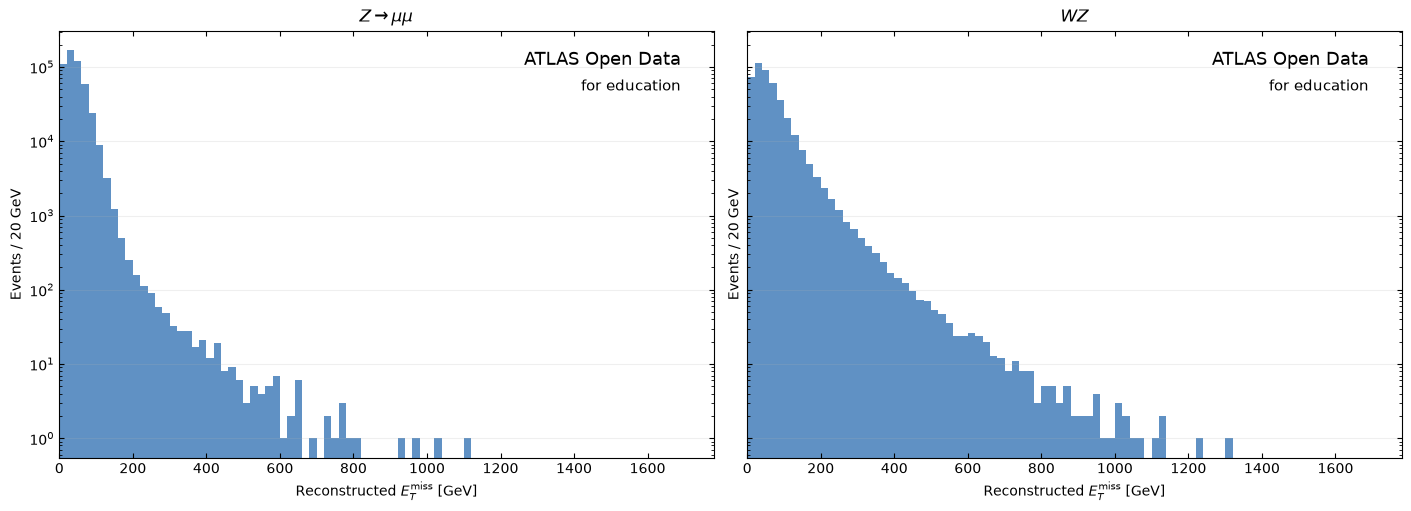

In [5]:
# Set the bin width and edges for the histograms
bin_width = 20
bin_edges = np.arange(0, 1770 + bin_width, bin_width)

# Create a figure with two subplots for the MET distributions of Z and WZ events
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5),
    sharex=True, sharey=True,
    layout="constrained",
)

# Plot the MET distributions for Z and WZ events
for ax, (sample_name, met_values) in zip(
    axes,
    [
        (r"$Z\rightarrow\mu\mu$", zmumu["met"]),
        (r"$WZ$", wz["met"]),
    ],
):
    ax.hist(
        met_values,
        bins=bin_edges,
        histtype="stepfilled",
        color="#2b6cb0",
        alpha=0.75,
    )
    ax.text(
        0.95, 0.92, "ATLAS Open Data",
        transform=ax.transAxes, ha="right", fontsize=13,
    )
    ax.text(
        0.95, 0.86, "for education",
        transform=ax.transAxes, ha="right", fontsize=11,
    )
    # Add labels, title, and grid to the plot
    ax.set_title(sample_name)
    ax.set_xlabel(r"Reconstructed $E_T^{\mathrm{miss}}$ [GeV]")
    ax.set_ylabel(f"Events / {bin_width} GeV")
    ax.set_xlim(bin_edges[0], bin_edges[-1])
    ax.set_yscale("log")
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.grid(axis="y", alpha=0.2)

plt.show()

### Reading the MET Spectrum 

First off, we can expect every sample from the $W$ decay to contain substantial genuine MET due to the guarantee of neutrinos. Now although the $Z\to\mu\mu$ simulation has no invisible particles included, we can expect it to also show *some* reconstructed MET. This is because the reconstruction process uses real detector activity and readings, with all of its real uncertainty, meaning that not *all* visible momenta will cancel. This detector-generated imbalance is what we'll be focusing on in this notebook.

The two spectra visualize those expectations, but neither graph defines an each MET occurrence as “genuine” or “instrumental.” If a $Z\to\mu\mu$ event appears far out on the horizontal axis, the plot does not yet say whether its truth MET is similarly high, or its reconstructed value is far from truth. Similarly, if a $WZ$ event has very large MET value, the plot does not explain whether the magnitude was measured correctly or not.

Therefore, our next step will be to try and identify the sources of our MET, and create plots that **will** define where MET comes from. We'll start by taking a closer look at our $WZ$ sample to see if our prompt MET, created by the sample's neutrinos, is accurately reconstructed. Then, we'll dig into our $Z\to\mu\mu$ sample to try and characterize a larger sample of non-prompt MET.

## MET scale: how well are we reconstructing?

The next step is to use the truth record as a reference. First we ask whether a real MET signal is reproduced **on average**; then we ask how far individual events wander from that reference. Scale graphs are used in analysis to understand if a reconstruction is behaving as it should. We take the average magnitudes of our truth MET ($E_{T,\mathrm{truth}}^{\mathrm{miss}}$) and our reconstructed MET ($E_{T,\mathrm{reco}}^{\mathrm{miss}}$) at varying energy levels and compare them with one another to see if our detector is misrepresenting our MET, and by how much.

Why use averages? We want to test the dectector's **response**, rather than let the scatter of individual events hide a systematic shift. This does come with drawbacks; for example, events measured 20 GeV too high and 20 GeV too low can give the correct mean while both individual measurements remain imprecise. We'll use another technique during our $Z\to\mu\mu$ study to rectify this.

In our $WZ$ sample, the leptonic $W$ decay provides genuine invisible momentum. If reconstruction reproduced every magnitude exactly, the points would lie on the diagonal $y=x$. A point above it indicates an average reconstructed MET larger than the average truth magnitude in that interval, while a point below it indicates the reverse. A consistent offset and a response that changes proportionally with truth MET would produce different departures from the diagonal. This means that variation from the line in either direction indicates we have instrumental MET in our sample!

Due to the values used being magnitudes, values on our scale graph will be positive. This means that a scale graph won't expose biases towards negative/positive components, but will only show us the *scale* to which reconstruction isn't (or is) lining up with truth information. Remember, MET is a vector quantity, so our magnitudes for the truth and reconstructed MET are calculated via:

$$
E_{T,\mathrm{truth/reco}}^{\mathrm{miss}}
=
\sqrt{(E_{x,\mathrm{truth/reco}}^{\mathrm{miss}})^2+
      (E_{y,\mathrm{truth/reco}}^{\mathrm{miss}})^2}
$$

The following cell will bin our values into energy ranges and create a set of averaged points for us to plot. We'll split things into 6 bins, where each bin creates 1 point representing the average truth MET and reconstructed MET across all events in that interval. We'll add horizontal bars to make the bin sizes more obvious, and the vertical bars will represent the uncertainty of each average. Bins will use truth MET intervals, so that we can still represent any "tails" with abnormally high reconstructed MET.

In [ ]:
wz_truth_et_miss = wz["truth_met"]
reco_et_miss = wz["met"]

scale_bin_edges = np.array(
    [0, 50, 100, 200, 500, 1000, 3000]
)

scale_points = []

for low, high in zip(
    scale_bin_edges[:-1],
    scale_bin_edges[1:],
):
    in_truth_bin = (
        (wz_truth_et_miss >= low)
        & (wz_truth_et_miss < high)
    )

    truth_values = wz_truth_et_miss[
        in_truth_bin
    ]

    reco_values = reco_et_miss[
        in_truth_bin
    ]

    finite_values = (
        np.isfinite(truth_values)
        & np.isfinite(reco_values)
    )

    truth_values = truth_values[
        finite_values
    ]

    reco_values = reco_values[
        finite_values
    ]

    n_events = len(reco_values)

    mean_truth = np.mean(truth_values)
    mean_reco = np.mean(reco_values)

    mean_reco_uncertainty = (
        np.std(reco_values, ddof=1)
        / np.sqrt(n_events)
    )

    scale_points.append(
        {
            "bin_low": low,
            "bin_high": high,
            "mean_truth_et_miss": mean_truth,
            "mean_reco_et_miss": mean_reco,
            "mean_reco_uncertainty": (
                mean_reco_uncertainty
            ),
            "events": n_events,
        }
    )

scale_table = pd.DataFrame(
    scale_points
)

scale_table

With this table we can look at more precise, numerical differences. However, a graph makes a systematic pattern easier to recognize. The next cell plots mean reconstructed MET against mean truth MET. The dashed $y=x$ line is our reference for equality of the two averages.

As you look at the next plot, think about how it may appear in different situations. If we reconstructed an extra 20 GeV per event, how might the graph change? How would that differ from a reconstructed value that is, on average, 20% too large at every truth scale? Would either pattern necessarily tell you how widely individual events fluctuate?

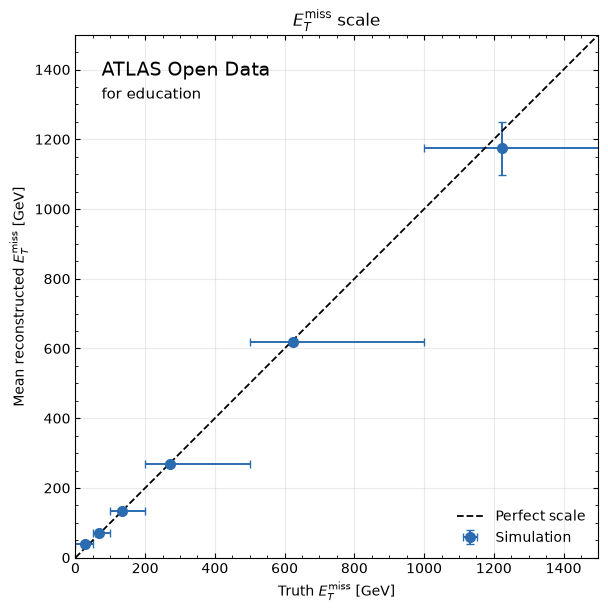

In [7]:
truth_scale_values = scale_table[
    "mean_truth_et_miss"
].to_numpy()

reco_scale_values = scale_table[
    "mean_reco_et_miss"
].to_numpy()

reco_scale_uncertainties = scale_table[
    "mean_reco_uncertainty"
].to_numpy()

scale_bin_lows = scale_table[
    "bin_low"
].to_numpy()

scale_bin_highs = scale_table[
    "bin_high"
].to_numpy()

truth_scale_xerr = np.vstack(
    [
        truth_scale_values - scale_bin_lows,
        scale_bin_highs - truth_scale_values,
    ]
)

fig, ax = plt.subplots(
    figsize=(7, 6),
    layout="constrained",
)

ax.errorbar(
    truth_scale_values,
    reco_scale_values,
    xerr=truth_scale_xerr,
    yerr=reco_scale_uncertainties,
    fmt="o",
    markersize=7,
    color="#2b6cb0",
    ecolor="#2b6cb0",
    elinewidth=1.4,
    capsize=3,
    label="Simulation",
)

scale_limit = 1500

ax.plot(
    [0, scale_limit],
    [0, scale_limit],
    color="black",
    linestyle="--",
    linewidth=1.3,
    label="Perfect scale",
)

ax.text(
    0.05,
    0.95,
    "ATLAS Open Data",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=14,
)

ax.text(
    0.05,
    0.90,
    f"for education",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=11,
)

ax.set_xlabel(
    r"Truth $E_T^{\mathrm{miss}}$ [GeV]"
)

ax.set_ylabel(
    r"Mean reconstructed $E_T^{\mathrm{miss}}$ [GeV]"
)

ax.set_title(
    r"$E_T^{\mathrm{miss}}$ scale"
)

ax.set_xlim(0, scale_limit)
ax.set_ylim(0, scale_limit)

ax.set_aspect(
    "equal",
    adjustable="box",
)

ax.legend(
    frameon=False,
    loc="lower right",
)

ax.tick_params(
    which="both",
    direction="in",
    top=True,
    right=True,
)

ax.xaxis.set_minor_locator(
    AutoMinorLocator()
)

ax.yaxis.set_minor_locator(
    AutoMinorLocator()
)

ax.grid(
    which="major",
    alpha=0.25,
)

plt.show()

### Reading the scale comparison

The first thing to notice is that, for the most part, our points fall pretty close to our "perfect scale" line. Our last point, from the 3000 GeV bin, has a very large vertical error bar, so it isn't fair to compare overall trends to this point. As we saw in the table, there are only 11 events in this interval, so we can consider this bin a "tail." Tails are the product of more uncommon phenomena in the detector, which can usually be attributed to incorrectly approximated reconstruction causing abnormally energetic events. Later we'll look a little more closely at these tails, and see how much they actually vary.

When interpereting a scale graph, we look first for a *pattern* of departures from the diagonal, not merely whether individual error bars touch it. Identifying directional biases, sometimes referred to as "systematic error," is a great first step in figuring out the nature of our detector errors. 

To think about our prior examples: If all events reconstructed 20 more GeV of MET than their truth values, we'd see an upwards offset to our points in the earlier bins, with the later bins generally averaging back to the perfect scale line. However, if each event reconstructed 20% more MET than their truth values, all points would be offset upwards from the perfect scale line. 

Until now, we've only been looking at the accuracy (how close to center on average) of our reconstructions. To study precision, we have to look closer at the event-by-event differences that averaging has concealed.

## Ordinary MET Errors

Next, let's look at some MET in a sample that shouldn't intrinsically contain much MET. From here, we'll shift to only using our $Z\to\mu\mu$ data, and study how MET crops up when there's no apparent MET source.

A $Z$ boson decaying to two muons produces no prompt neutrino. Both muons and the rest of the visible event should balance in transverse momentum when everything is accounted for, ideally with no remainder. In practice, their reconstructed momenta don't ofter balance exactly. Jets can only be approximated so precisely, particles may fall below reconstruction thresholds or outside an accepted region, particles may scatter or take abnormal paths through the detector, and softer activity must also be estimated. The resulting MET values give us a way to investigate how reconstruction fluctuates.

A lack of invisible particles does **not** mean truth MET is set to zero for every simulated event. The event record provides a truth reference, and some events can, and will, have nonzero truth MET. This means that presence of reconstructed MET does not immediately indicate error. Using these truth MET values, we can expose how much the reconstruction MET deviates from our precursor truth values, allowing us to precisely study the error in the reconstruction.

What is **resolution**, and how can we use it here? Imagine repeating a measurement for many comparable events, like in a Monte Carlo reconstruction. Even if the method has the correct average response, its answers will vary around the corresponding truth values. Resolution describes the characteristic size of that event-to-event variation. A narrow distribution means typical measurements stay close to truth, while a broad distribution means they often differ appreciably. Resolution is one of many measurements used in describing MET, along with:

- **Scale:** a systematic tendency for reconstructed values to be high or low.
- **Uncertainty on an average:** how precisely a large sample determines its mean.
- **Tail:** how unusually large discrepancies occur.

We will make those distinctions visible in three steps. First, we'll calculate the overall deviation using graphs known as **residuals**. Second, we'll dissect these graphs to understand what their underlying characterists can reveal to us. Third, repeat the comparison in event categories with different levels activity, as a useful resolution model must describe the environments in which MET is used.

We'll start by comparing how much each event differs in each $x$ and $y$, from their truth values, along with the overall magnitude distribution. This will show us if there are any larger $xy$ biases in our reconstructed MET, and allow us to see the general energies our MET is concentrated around. Truth MET is supplied as a magnitude and angle, known as Phi ($\phi$), which is a component of the [ATLAS Coordinate System](https://cds.cern.ch/record/2951041/files/ATLAS%20Coordinate%20System.pdf). We will reconstruct its Cartesian components using:

$$
E_{x,\mathrm{truth}}^{\mathrm{miss}}
=
E_{T,\mathrm{truth}}^{\mathrm{miss}}\cos\phi_{\mathrm{truth}},
\qquad
E_{y,\mathrm{truth}}^{\mathrm{miss}}
=
E_{T,\mathrm{truth}}^{\mathrm{miss}}\sin\phi_{\mathrm{truth}}.
$$

We then subtract truth from reconstruction for each **same event**.

In [ ]:
# Retain the supplied truth MET: do not assume it is identically zero.
zmumu["truth_ex"] = (
    zmumu["truth_met"] * np.cos(zmumu["truth_met_phi"])
)
zmumu["truth_ey"] = (
    zmumu["truth_met"] * np.sin(zmumu["truth_met_phi"])
)

zmumu["residual_x"] = zmumu["met_mpx"] - zmumu["truth_ex"]
zmumu["residual_y"] = zmumu["met_mpy"] - zmumu["truth_ey"]
zmumu["residual_t"] = zmumu["met"] - zmumu["truth_met"]

print(f"Events used for residuals: {len(zmumu['residual_x']):,}")

The code has calculated the residual values:

$$
\Delta E_x^{\mathrm{miss}}
=
E_{x,\mathrm{reco}}^{\mathrm{miss}}
-
E_{x,\mathrm{truth}}^{\mathrm{miss}},
\qquad
\Delta E_y^{\mathrm{miss}}
=
E_{y,\mathrm{reco}}^{\mathrm{miss}}
-
E_{y,\mathrm{truth}}^{\mathrm{miss}},
$$

as well as reconstructed minus truth **magnitude**. These $\Delta E^{\mathrm{miss}}$ values are known in isolation as residuals, though the term residual is often used in reference to residual graphs. Each residual value is the answer to “How far was this reconstructed quantity from its simulated reference?”

To learn what is *typical* at all energies, we need the distribution across many events. The next figure provides three views of that distribution, giving us our first residual graphs. Pay attention to three key features of the graph: its **center** (a possible systematic shift), its **central spread** (ordinary variation), and its **far entries** (unusually large discrepancies).

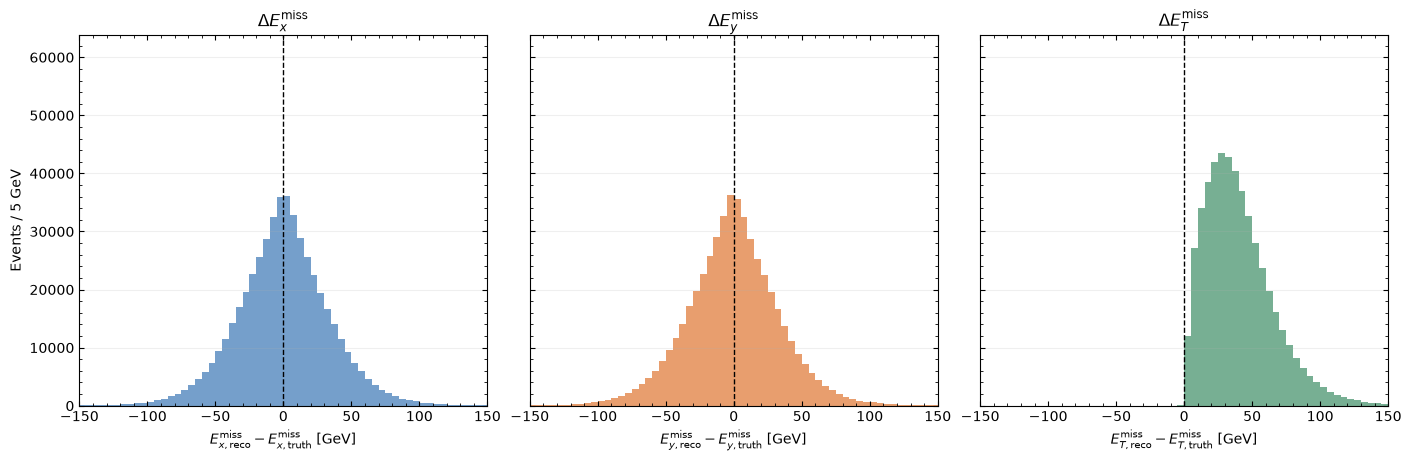

In [9]:
residual_bin_width = 5
residual_edges = np.arange(-150, 155, residual_bin_width)

fig, axes = plt.subplots(
    1, 3, figsize=(14, 4.5),
    sharey=True, layout="constrained",
)

residual_plots = [
    ("residual_x", "x", "#2b6cb0"),
    ("residual_y", "y", "#dd6b20"),
    ("residual_t", "T", "#2f855a"),
]

for ax, (name, component, color) in zip(axes, residual_plots):
    ax.hist(
        zmumu[name],
        bins=residual_edges,
        histtype="stepfilled",
        density=False,
        color=color,
        alpha=0.65,
    )
    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title(rf"$\Delta E_{{{component}}}^{{\mathrm{{miss}}}}$")
    ax.set_xlabel(
        rf"$E_{{{component},\mathrm{{reco}}}}^{{\mathrm{{miss}}}}"
        rf"-E_{{{component},\mathrm{{truth}}}}^{{\mathrm{{miss}}}}$ [GeV]"
    )
    ax.set_xlim(residual_edges[0], residual_edges[-1])
    ax.tick_params(which="both", direction="in", top=True, right=True)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.grid(axis="y", alpha=0.2)

axes[0].set_ylabel(f"Events / {residual_bin_width} GeV")
axes[0].set_ylim(0, 1.4 * axes[0].get_ylim()[1])

plt.show()

### Reading the residual distributions

The signed $x$ and $y$ residuals preserve direction, showing us if there is a skew in a negative or positive reading. A positive $\Delta E_x^{\mathrm{miss}}$ says the reconstructed $x$ component is more positive than its truth component, and vice versa. If a signed distribution is centered near zero, positive and negative deviations roughly balance, directly hinting at the overall **bias in that component**. Its width tells us how far individual measurements usually wander from truth.

Remember, the magnitude residual is calculated slightly differently,

$$
\Delta E_T^{\mathrm{miss}}
=
E_{T,\mathrm{reco}}^{\mathrm{miss}}
-
E_{T,\mathrm{truth}}^{\mathrm{miss}}.
$$

Such that the magnitude of a composite residual vector is not represented by the equation

$$
\Delta E_T^{\mathrm{miss}}
\ne
\sqrt{(\Delta E_x^{\mathrm{miss}})^2+
      (\Delta E_y^{\mathrm{miss}})^2}.
$$

The left side compares two *lengths*; the right side asks how far apart two vectors are. For a simple zero-truth-MET example, suppose the signed reconstructed components fluctuate symmetrically around zero. They may show no preferred $x$ or $y$ direction, yet their combined length is positive for almost every event. Thus a positive magnitude residual does not automatically contradict centered component residuals.

**Check your understanding:** 
1. Could a component residual be centered at zero but very broad? 
2. What would it mean for a component residual to be centered at, say, -50 GeV?
3. What does it mean if two residuals are the same width, but one has spikes at far-out energies? 

<details>
<summary>Click here to reveal the answers!</summary>

1. Yes! Positive and negative errors can cancel in the mean while many individual events are poorly measured. 
2. This suggests that on average, events in your sample are reconstructing 50 *less* GeV of MET. This could mean that a particular reconstruction is giving *too much* momentum to the particles in the simulation, giving us energy where there shouldn't be any!
3. Like we mentioned before, this is due to the presence of tails. Separating tails from our main distributions is what differentiates between what we call “resolution” and what we must study separately.

</details>

## Jets, Residuals, and Resolution

Our previous residual plots give us a feel of how MET appears in our sample very generally. However, as you may notice, we only show the [-150,150] interval, and we plot all of the events uniformly, effectively averaging things out once again. To continue getting a clearer picture of the specific error throughout the sample, we'll start by splitting things up such that we can take error readings at different energy levels. To do this, we'll sample the residual MET in the x axis, but split events up into intervals tied to their jet activity, so we can get a better picture of how error crops up at different energy scales.

Why discuss jets in a $Z\to\mu\mu$ sample? We'll specifically be focusing on the hadronic decay jets, which the two muons can recoil against, rather than its decay products. Quarks and gluons produced at high energies in the initial collision can form runaway decays which we call jets, along with softer activity from resultant jets and pile-up. When we reconstruct Monte Carlo samples, we include how the particles in a sample would react to non-prompt and soft activity during a collision, as to better approximate what the decay would look like in data A $Z\to\mu\mu$ event therefore is not necessarily a “two muons and nothing else” event. 

That makes the sample useful for our question. The $Z$ decay itself supplies no prompt neutrino, but the amount of visible hadronic activity varies from event to event. We can keep the decay channel fixed while asking whether MET reconstruction behaves differently in quieter and more jet-active events.

We summarize **selected jets** with

$$
H_T=\sum_{\mathrm{selected\ jets}}p_T^{\mathrm{jet}},
\qquad
p_T^{\mathrm{jet}}>20\ \mathrm{GeV},
\quad |\eta^{\mathrm{jet}}|<2.5.
$$

Here $p_T$ is a jet's transverse-momentum magnitude, and $\eta$ describes its direction relative to the beam in the ATLAS Coordinate System. $H_T$ adds positive magnitudes: two opposite 100 GeV jets contribute 200 GeV to $H_T$, even if their momentum vectors balance. MET instead comes from a **vector** imbalance. High $H_T$ is therefore a description of selected-jet activity, not a claim that an event has high genuine MET. We also apply selection criteria to the jets to rule out poorly contributing, low-energy jet candidates. Setting the minimum energy to 20 GeV assures that our jets are sufficiently energetic such that there are more likely valid jets, while the $|\eta|$ requirement makes sure our included jets are significantly contributing to the transverse activity of the sample.

What about events with **no selected jets**? The sum over an empty set is zero, so it has $H_T=0$ and belongs in the first interval, $[0,50)$ GeV. It may still contain the two muons, softer jets, jets outside our angular selection, and the MET soft term. “No selected jets” is not “nothing visible,” and $H_T$ is not the total activity entering MET reconstruction.

We use $H_T$ because it lets us order events by one aspect of their visible activity. Binning by truth MET would tell us little about the reconstructed activity in this sample. Binning by **reconstructed MET magnitude** would be more problematic for this particular overlay, as the magnitude is built from the same components whose residuals we are plotting, and selecting a narrow magnitude range can geometrically create twin peaks in a signed component. $H_T$ is still related to MET reconstruction through the jets, but it does not impose that direct magnitude constraint.

The next cell counts events in $[0,50)$, $[50,100)$, $[100,200)$, $[200,400)$, $[400,800)$, $[800,1500)$, and $[1500,3000)$ GeV. It will also return a mulitiplicity readout, so we can take a look at how many events are represented in each bin!

In [ ]:
ht_bin_edges = np.array([0, 50, 100, 200, 400, 800, 1500, 3000])
ht_residual_groups = []

for low, high in zip(ht_bin_edges[:-1], ht_bin_edges[1:]):
    in_bin = (zmumu["ht"] >= low) & (zmumu["ht"] < high)
    residuals = zmumu["residual_x"][in_bin]
    n_events = len(residuals)

    print(f"H_T [{low}, {high}) GeV: {n_events:,} events")

    # Match the minimum used by the later resolution calculation.
    if n_events >= 10:
        ht_residual_groups.append((low, high, residuals))

### What are we about to compare?

The printed counts tell us how many $Z\to\mu\mu$ events enter each $H_T$ interval. Similar to our last residual plots, we'll plot residual energies versus some form of multiplicity. However, with 7 intervals to look at, we'll overlay these graphs onto the same plot, letting us better compare the distributions directly. The code retains intervals with at least ten events for the overlay, matching the minimum used later for the numerical width. The next plot keeps the **horizontal quantity unchanged**, where every curve shows

$$
\Delta E_x^{\mathrm{miss}}
=
E_{x,\mathrm{reco}}^{\mathrm{miss}}
-
E_{x,\mathrm{truth}}^{\mathrm{miss}}.
$$

For these residuals, we'll also shift the $y$-axis from multiplicity to a probability density. This gives us a better chance to visualize fluctuations without using a logarithmic view, which would obscure the overall shape and width of these distrobutions. Each histogram bin is weighted by the reciprocal of that category's event count. The vertical axis is therefore the **fraction of events in that category per 5 GeV residual interval**, rather than a raw event count. Splitting things up like this allows us to visualize how things change as activity increases, with equal emphasis placed in areas which are averaged out in our prior distributions.

Before looking at the next plot, take a second and think about a few things: If $x$ residual values become larger as jet activity increases, would you expect the high-$H_T$ curve to keep the same sharp central concentration as we saw before? How might our final bin, with its few events, look? What might the average *width* of these distributions represent? How might things change as we move along bins?

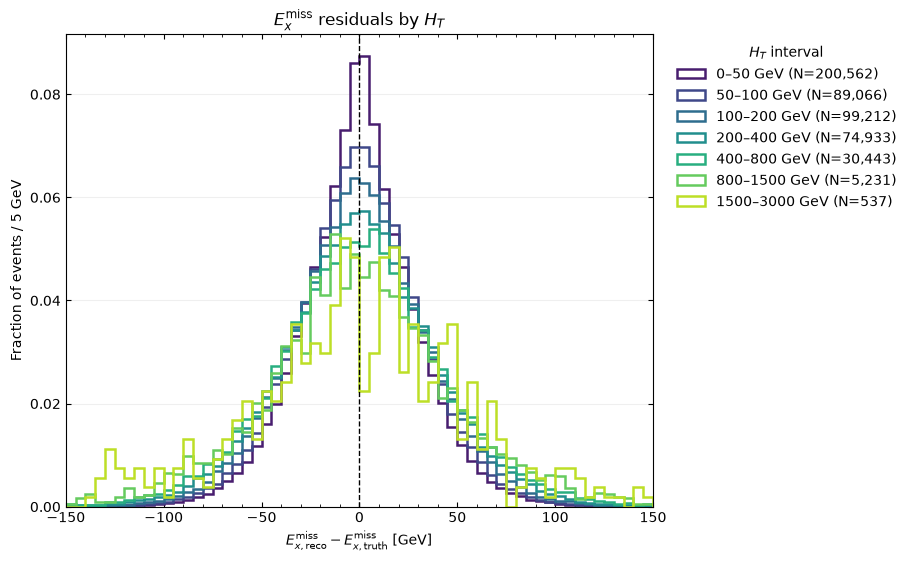

In [11]:
fig, ax = plt.subplots(figsize=(9, 5.5), layout="constrained")
colors = plt.get_cmap("viridis")(
    np.linspace(0.08, 0.90, len(ht_residual_groups))
)

for color, (low, high, residuals) in zip(colors, ht_residual_groups):
    ax.hist(
        residuals,
        bins=residual_edges,
        weights=np.full(len(residuals), 1 / len(residuals)),
        histtype="step",
        linewidth=1.8,
        color=color,
        label=f"{low}–{high} GeV (N={len(residuals):,})",
    )

ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title(r"$E_x^{\mathrm{miss}}$ residuals by $H_T$")
ax.set_xlabel(
    r"$E_{x,\mathrm{reco}}^{\mathrm{miss}}"
    r"-E_{x,\mathrm{truth}}^{\mathrm{miss}}$ [GeV]"
)
ax.set_ylabel(f"Fraction of events / {residual_bin_width} GeV")
ax.set_xlim(residual_edges[0], residual_edges[-1])
ax.legend(
    title=r"$H_T$ interval",
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.grid(axis="y", alpha=0.2)

plt.show()

### Interpereting a "Binned" Residual

Now that we can relate residual MET to something (in our case, jet activity), we can ask a more direct question: **does the signed MET discrepancy change in relation to the jet activity in an event?**

We can start by reading the overlay from the center outward. A curve concentrated near zero indicates that a larger fraction of its events have small $x$ discrepancies. A curve spread across more residual bins indicates a broader range of reconstructed-minus-truth values. For our lower-multiplicity curves, notice secondary peaks or ridges extending outwards over multiple energies. We can understand that the average variation from 0 in a disribution is approximately represented by the width of the "middle" of each distribution. This is a crucial detail to our analysis, as understanding the average variation at each energy scale can help us solve one possible source for our MET discrepancy!

**Check your prediction:** Did each plot appear as you expected? Are the high-$H_T$ curves smooth enough to support a detailed visual claim? 

The overlay can suggest a trend, but “this curve looks wider” is not yet a reproducible measurement. We need to decide what part of a residual distribution we mean by **width**, and calculate it the same way in every $H_T$ interval. Once we can extract these values, we can visualize our *resolution*

with every method, there are drawbacks as well. $H_T$ changes with jet momentum, but events with different $H_T$ can also differ in jet number, recoil, soft activity, and other properties. A change in residual shape establishes a relationship with our chosen event category, but it does not rule out every possible cause. For a formal analysis, taking resolutions across different causes is important to prove the cause of residual MET, and allows you to observe physical phenomena unobstructed.

### Quantifying our Residuals

As we said, our next step is to turn what our average width "looks like" into a real quantity. The **median residual** of a distrobution describes the center of the signed $x$ differences. Its **central 68% half-width** describes how widely the ordinary events spread around that center, and is calculated via:

$$
\sigma_{68}(\Delta E_x^{\mathrm{miss}})
=
\frac{Q_{84}-Q_{16}}{2}.
$$

$Q_{16}$ is the residual below which 16% of the group's events lie, while $Q_{84}$ is the value below which 84% lie. The interval between them therefore contains the central 68% of events. For a Gaussian distribution, its half-width is approximately one standard deviation. However, using this percentile definition helps us account for if (in most cases, when) a residual distribution is not perfectly Gaussian.

Why do we measure the central 68% instead of using the full range, using something like the root-mean-squared? We do this because of a familiar issue: tails. A single very energetic residual could drastically shift the half-width of an entire bin while telling us little about the accuracy of an **ordinary** event. The percentile width is our answer to the issues that arise from tails in our samples! This also allows us to study the tails of a sample in isolation, giving us a chance to check for any new phenomena which could be causing them.

The following cell will calculate our half-widths. Read the table by comparing its columns, not just its widths. A median near zero and a large $\sigma_{68}$ mean positive and negative discrepancies may balance *on average* while individual events vary substantially. The `events` column tells us how much information supports each row. The bootstrap uncertainty is calculated by repeatedly resampling the group's events and recalculating its percentile width. It describes uncertainty in our **estimate of the width**, and is a great extra step to insure that we have as much information on the variation in our sample as possible.

In [ ]:
ht_bin_edges = np.array([0, 50, 100, 200, 400, 800, 1500,3000])
n_bootstrap = 500
bootstrap_batch_size = 8
rng = np.random.default_rng(42)

ht_resolution_points = []

for low, high in zip(ht_bin_edges[:-1], ht_bin_edges[1:]):
    in_bin = (zmumu["ht"] >= low) & (zmumu["ht"] < high)
    residuals = zmumu["residual_x"][in_bin]
    n_events = len(residuals)

    if n_events < 10:
        print(f"Skipping HT [{low}, {high}) GeV: {n_events} events.")
        continue

    q16, median, q84 = np.percentile(residuals, [16, 50, 84])
    sigma_x = 0.5 * (q84 - q16)

    bootstrap_widths = np.empty(n_bootstrap)

    for start in range(0, n_bootstrap, bootstrap_batch_size):
        stop = min(start + bootstrap_batch_size, n_bootstrap)
        indices = rng.integers(
            0, n_events, size=(stop - start, n_events)
        )
        quantiles = np.percentile(
            residuals[indices], [16, 84], axis=1
        )
        bootstrap_widths[start:stop] = (
            quantiles[1] - quantiles[0]
        ) / 2

    ht_resolution_points.append(
        {
            "bin_low": low,
            "bin_high": high,
            "mean_ht": np.mean(zmumu["ht"][in_bin]),
            "median_residual": median,
            "sigma_x": sigma_x,
            "sigma_x_uncertainty": np.std(bootstrap_widths, ddof=1),
            "events": n_events,
        }
    )

ht_resolution_table = pd.DataFrame(ht_resolution_points)

if ht_resolution_table.empty:
    raise ValueError("No HT interval contains enough valid events.")

display(ht_resolution_table)

Now that we have these values calculated, we'll construct a graph which places these widths at the mean $H_T$ of their groups. 

**Before viewing it:** Based on the overlay, what trend can you predict? If the points rise, what exactly has increased? The average MET magnitude, the bias of the $x$ residual, or its central event-to-event spread?

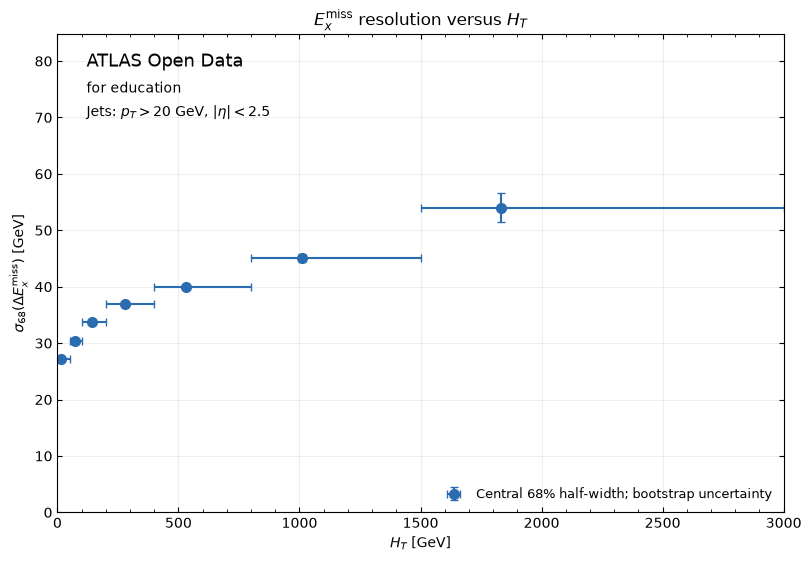

In [13]:
ht_points = ht_resolution_table["mean_ht"].to_numpy()
ht_sigma_x = ht_resolution_table["sigma_x"].to_numpy()
ht_sigma_x_uncertainty = ht_resolution_table[
    "sigma_x_uncertainty"
].to_numpy()

ht_xerr = np.vstack(
    [
        ht_points - ht_resolution_table["bin_low"].to_numpy(),
        ht_resolution_table["bin_high"].to_numpy() - ht_points,
    ]
)

fig, ax = plt.subplots(figsize=(8, 5.5), layout="constrained")

ax.errorbar(
    ht_points,
    ht_sigma_x,
    xerr=ht_xerr,
    yerr=ht_sigma_x_uncertainty,
    fmt="o",
    markersize=7,
    capsize=3,
    color="#2b6cb0",
    label="Central 68% half-width; bootstrap uncertainty",
)

ax.set_xlabel(r"$H_T$ [GeV]")
ax.set_ylabel(r"$\sigma_{68}(\Delta E_x^{\mathrm{miss}})$ [GeV]")
ax.set_title(r"$E_x^{\mathrm{miss}}$ resolution versus $H_T$")
ax.set_xlim(ht_bin_edges[0], ht_bin_edges[-1])
ax.set_ylim(0, 1.5 * np.max(ht_sigma_x + ht_sigma_x_uncertainty))
ax.legend(frameon=False, loc="lower right", fontsize=9)
ax.grid(axis="y", alpha=0.2)
ax.grid(axis="x", alpha=0.2)
ax.text(0.04, 0.96, "ATLAS Open Data",transform=ax.transAxes,va="top", fontsize=13,)
ax.text(0.04, 0.90, "for education",transform=ax.transAxes,va="top", fontsize=10,)
ax.tick_params(which="both", direction="in", top=True, right=True)
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.text(
    0.04, 0.85,
    r"Jets: $p_T>20$ GeV, $|\eta|<2.5$",
    transform=ax.transAxes,
    va="top", fontsize=10,
)

plt.show()

### What can we see?

Each point represents the average half-width from the overlays we constructer prior. Its horizontal position is that group's mean $H_T$, while the horizontal bars show the boundaries of the bin. Its vertical position is the half-width ($\sigma_{68}$) of the signed $x$ residual, and its vertical bars show the bootstrap uncertainty on that estimated width.

If the points rise as $H_T$ increases, this indicates the typical $x$ discrepancy is broader in groups with more jet activity. With this, we can definitively say that there is a positive relationship between reconstructed MET and jet activity! Based on what we set as our binning variable, we can use resolution to learn a lot about what is causing residual MET in a sample. What does this graph **not** say? It does not prove that one particular jet caused a particular MET error. It does not measure a full event-by-event MET significance, which would account for object directions and expected uncertainties in more detail. And as we said before, it does not describe rare, extreme residual values.

**Comprehension check:** Suppose two $H_T$ groups have similarly centered residuals but very different $\sigma_{68}$ values. Which group is more biased? Can you tell from the widths alone? Which group has poorer ordinary $x$ precision? These are separate questions; the graph answers the second one.

## Inspecting those tails!

With our prior resolution graph, we focused on the deviation of *ordinary* events. But what about those stragglers living far outside of the mean? 

Imagine two reconstruction methods with the same $\sigma_{68}$. One almost never produces a huge discrepancy. The other usually performs just as well but occasionally fails dramatically. A central-width graph might barely distinguish them, while a high-MET search would be affected very differently. We must directly inspect the tail rather than assume error is uniform across the sample.

The next code cell counts $Z\to\mu\mu$ events with **reconstructed** MET above 1 TeV. These are events to investigate, not events already diagnosed as failures. We'll only use reconstructed MET here, as truth MET in samples with no prompt MET are often much lower. We can then graph these points in comparison to $H_T$ to check if these values follow our earlier trend, or if a more in-depth inspection is required. While it may seem like one could simply explain things with random error every time, high-energy tails are often used in searches for new phenomena, and can offer important insights into real physical phenomena!

In [ ]:
high_met_selection = zmumu["met"] > 1000

high_met_values = zmumu["met"][high_met_selection]
high_met_ht_values = zmumu["ht"][high_met_selection]

print(
    f"Z→μμ events with reconstructed MET > 1 TeV: "
    f"{len(high_met_values):,}"
)

### What can we learn from these selected events?

We now know how many events passed the reconstructed-MET requirement. The next plot places **one point per selected event** at its reconstructed MET magnitude and selected-jet $H_T$. The dashed 1 TeV line marks the selection boundary, showing how drastic deviations are.

Before viewing the figure, consider:

- An event at high MET and high $H_T$ contains substantial selected-jet activity. Could this suggest mismeasurement in our jets?
- An event at high MET and low $H_T$ has little jet activity. What could this indicate?

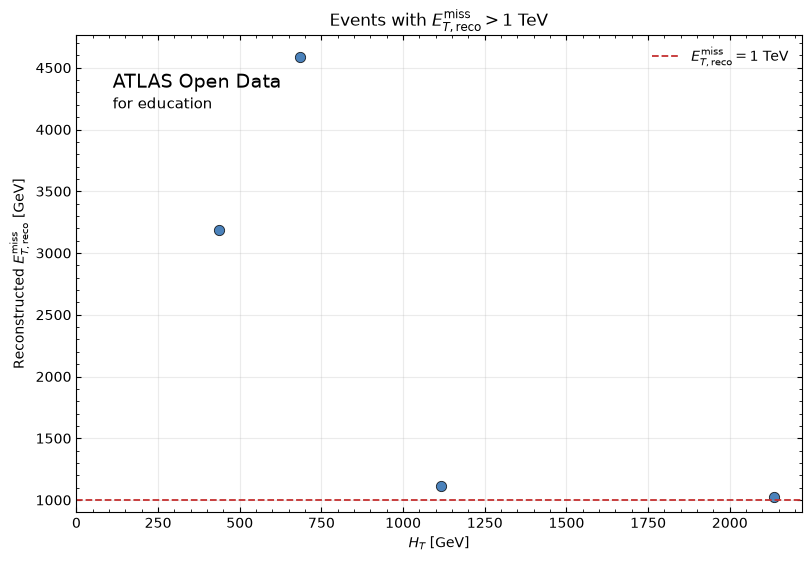

In [15]:
fig, ax = plt.subplots(
    figsize=(8, 5.5),
    layout="constrained",
)

ax.scatter(
    high_met_ht_values,
    high_met_values,
    s=55,
    color="#2b6cb0",
    edgecolor="black",
    linewidth=0.6,
    alpha=0.85,
)

ax.axhline(
    1000,
    color="#c53030",
    linestyle="--",
    linewidth=1.3,
    label=r"$E_{T, \mathrm{reco}}^{\mathrm{miss}}=1$ TeV",
)

ax.text(
    0.05,
    0.92,
    "ATLAS Open Data",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=14,
)

ax.text(
    0.05,
    0.87,
    f"for education",
    transform=ax.transAxes,
    verticalalignment="top",
    fontsize=11,
)

ax.set_xlabel(
    r"$H_T$ [GeV]"
)

ax.set_ylabel(
    r"Reconstructed $E_{T, \mathrm{reco}}^{\mathrm{miss}}$ [GeV]"
)

ax.set_title(
    r"Events with $E_{T, \mathrm{reco}}^{\mathrm{miss}}>1$ TeV"
)

ax.set_xlim(left=0)
ax.set_ylim(bottom=900)

ax.legend(
    frameon=False,
    loc="upper right",
)

ax.tick_params(
    which="both",
    direction="in",
    top=True,
    right=True,
)

ax.xaxis.set_minor_locator(
    AutoMinorLocator()
)

ax.yaxis.set_minor_locator(
    AutoMinorLocator()
)

ax.grid(
    which="major",
    alpha=0.25,
)

plt.show()

### Interpreting the high-MET scatter plot

We know each point tell us that **this simulated $Z\to\mu\mu$ event was reconstructed with more than 1 TeV of MET**, and its horizontal position gives the amount of jet activity in the event which produced each MET value.

High $H_T$ means energetic selected jets are present, and could contribute, but in many cases that's only part of the study. Points appearing at low $H_T$ does not indicate complete mismeasurement either, as the event still contains muons and may contain jets outside our selection and other activity. Further, choosing events using reconstructed MET, upward reconstruction fluctuations are preferred in this set over downward fluctuations.

To track down the source of a tail in simulation, we would next ask:

1. What are its truth MET magnitude and direction?
2. How large is its reconstructed-minus-truth **vector** difference?
3. What visible objects and soft activity contribute to the reconstructed momentum balance?
4. Does the discrepancy align with a plausible missed or poorly measured contribution?

## Summary

You've made it to the end of the Missing Transverse Energy notebook! So, what have we learned? Firstly, MET is the momentum needed to balance the reconstructed visible event in the transverse plane. Conservation of momentum makes that inference possible, but an imbalance has more than one explanation. Invisible particles can carry momentum away, but imperfect reconstruction of visible activity can also leave a nonzero vector sum.

From our plots, we saw:

- Prompt neutrinos can change our expectations, but MET can appear in all sample types.
- We can test response across truth-MET intervals to feel for systematic errors in data.
- Analyzing signed components can reveal direction-dependent biases and greater event-to-event spread. 
- By dividing up our sample based on some aspect of an event, we can analyze how MET changes across a sample.
- Comparing these divisions with one another allows us to spot how aspects of an event can change the average MET values.
- High-energy tails don't always fall in line with other sources of MET, and need deeper analysis to justify them.

If you're interested in learning more, here are some tips and further learning prompts to think about:

- Remember, MET magnitude says how large the imbalance is, but its direction can help diagnose what is missing from the visible momentum sum.
- Always read the selection before the plot. Our final sample was selected on *reconstructed* MET, which changes what can be inferred from its scatter plot.
- The high-MET set is small and drawn from a limited, unweighted simulated sample. Avoid turning a few points into a claim about an entire sample.
- For each event above 1 TeV reconstructed MET, try comparing reconstructed and truth MET vectors. Which events are dominated by genuine truth MET, and which by a large reconstruction discrepancy?
- Try calculating what *fraction* of events in a certain bin might pass a high-energy threshold.
- For a high-MET event with selected jets, what is the angle between the MET vector and that jet? What pattern might a jet measured too low produce, and what other explanations could produce a similar pattern?
- Now and then, extreme approximation errors leave events with MET values that equal or exceed the energy of the initial proton-proton collision. While these are always due to detector issues, finding them in data can be fun and studying them can help you understand MET in the context of instrumentation. 


<div class="alert alert-block alert-info">
We welcome your feedback on this notebook or any of our other materials! Please <a href="https://forms.gle/zKBqS1opAHHemv9U7">fill out this survey</a> to let us know how we're doing, and you can enter a raffle to win some <a href="https://atlas-secretariat.web.cern.ch/merchandise">ATLAS merchandise</a>!
</div>